# Task 1

The team at RealAgents knows that the city that a property is located in makes a difference to the sale price.

Unfortuntately they believe that this isn't always recorded in the data.

Calculate the number of missing values of the `city`.

 - You should use the data in the file "house_sales.csv".

 - Your output should be an object `missing_city`, that contains the number of missing values in this column.

In [16]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.impute import SimpleImputer

import seaborn as sns

from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import r2_score

from google.colab import drive
drive.mount('/content/drive')



Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/Exam_Original.xlsx')

df.head()

,index,house_id,city,sale_price,sale_date,months_listed,bedrooms,house_type,area
0,0,1217792,Silvertown,55943,2021-09-12,5.4,2,Semi-detached,107.8 sq.m.
1,1,1900913,Silvertown,384677,2021-01-17,6.3,5,Detached,498.8 sq.m.
2,2,1174927,Riverford,281707,2021-11-10,6.9,6,Detached,542.5 sq.m.
3,3,1773666,Silvertown,373251,2020-04-13,6.1,6,Det.,528.4 sq.m.
4,4,1258487,Silvertown,328885,2020-09-24,8.7,5,Detached,477.1 sq.m.


In [3]:
# Use this cell to write your code for Task 1
missing_city = df['city'].loc[df['city'] == '--']
missing_city = int(missing_city.count())

missing_city

73

# Task 2

Before you fit any models, you will need to make sure the data is clean.

The table below shows what the data should look like.

Create a cleaned version of the dataframe.

 - You should start with the data in the file "house_sales.csv".

 - Your output should be a dataframe named `clean_data`.

 - All column names and values should match the table below.


| Column Name | Criteria                                                |
|-------------|---------------------------------------------------------|
| house_id    | Nominal. </br> Unique identifier for houses. </br>Missing values not possible. |
| city        | Nominal. </br>The city in which the house is located. One of 'Silvertown', 'Riverford', 'Teasdale' and 'Poppleton' </br>Replace missing values with "Unknown". |
| sale_price  | Discrete. </br>The sale price of the house in whole dollars. Values can be any positive number greater than or equal to zero.</br>Remove missing entries. |
| sale_date   | Discrete. </br>The date of the last sale of the house. </br>Replace missing values with 2023-01-01. |
| months_listed  | Continuous. </br>The number of months the house was listed on the market prior to its last sale, rounded to one decimal place. </br>Replace missing values with mean number of months listed, to one decimal place. |
| bedrooms    | Discrete. </br>The number of bedrooms in the house. Any positive values greater than or equal to zero. </br>Replace missing values with the mean number of bedrooms, rounded to the nearest integer. |
| house_type   | Ordinal. </br>One of "Terraced", "Semi-detached", or "Detached". </br>Replace missing values with the most common house type. |
| area      | Continuous. </br>The area of the house in square meters, rounded to one decimal place. </br>Replace missing values with the mean, to one decimal place. |

In [8]:
# Use this cell to write your code for Task 2

df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/Exam_Original.xlsx')


#city treatment and fillna
df['city'].replace('--',np.NaN, inplace=True)

dict_fill = {
    'city': 'Unknown',
    'sale_date': '2023-01-01',
    'months_listed': np.NaN,
    'area': ''
}

df.fillna(dict_fill, inplace=True)

df['city'] = df['city'].astype('category')

#sale price treatment
df['sale_price'] = df['sale_price'].astype(int)

#months_listed
imp_mean = SimpleImputer(missing_values=np.NaN, strategy='mean')
months_adj = imp_mean.fit_transform(df[['house_id', 'months_listed']])
idf = pd.DataFrame(months_adj, columns=['house_id', 'months_listed'])

df = pd.merge(df, idf, how='inner', on=['house_id'])
df['months_listed_y'] = df['months_listed_y'].apply(lambda x: round(x, 1))
df.rename(columns={'months_listed_y': 'months_listed'}, inplace=True)


# modify_columns = ['house_id', 'city', 'sale_price', 'sale_date', 'months_listed_y', 'bedrooms', 'house_type', 'area']

# df = df[modify_columns]


# #bedrooms
# #Its ok


#house_type treatment
def house_type_adj(item):
    if item[0] == 'S':
        return 'Semi-detached'
    elif item[0] == 'D' :
        return 'Detached'
    else:
        return 'Terraced'

df['house_type'] = df['house_type'].apply(house_type_adj)

#Aplicar categorical a campo house_type ya que es una variable ordinal
house_cat = ['Terraced', 'Semi-detached', 'Detached' ]

df['house_type'] = pd.Categorical(df['house_type'], categories=house_cat, ordered=False)

#area treatment
def area_adj(item):
    area_casting = round(float(item[:5]), 1)
    return area_casting

df['area'] = df['area'].apply(area_adj)


columns = ['house_id', 'city', 'sale_price', 'sale_date', 'months_listed', 'bedrooms', 'house_type', 'area']

clean_data = df[columns]

print(clean_data.info())
clean_data




<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1500 entries, 0 to 1499
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype   
---  ------         --------------  -----   
 0   house_id       1500 non-null   int64   
 1   city           1500 non-null   category
 2   sale_price     1500 non-null   int64   
 3   sale_date      1500 non-null   object  
 4   months_listed  1500 non-null   float64 
 5   bedrooms       1500 non-null   int64   
 6   house_type     1500 non-null   category
 7   area           1500 non-null   float64 
dtypes: category(2), float64(2), int64(3), object(1)
memory usage: 73.7+ KB
None


<ipython-input-8-a57c5da892dc>:7: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['city'].replace('--',np.NaN, inplace=True)


,house_id,city,sale_price,sale_date,months_listed,bedrooms,house_type,area
0,1217792,Silvertown,55943,2021-09-12,5.4,2,Semi-detached,107.8
1,1900913,Silvertown,384677,2021-01-17,6.3,5,Detached,498.8
2,1174927,Riverford,281707,2021-11-10,6.9,6,Detached,542.5
3,1773666,Silvertown,373251,2020-04-13,6.1,6,Detached,528.4
4,1258487,Silvertown,328885,2020-09-24,8.7,5,Detached,477.1
...,...,...,...,...,...,...,...,...
1495,1123892,Riverford,198661,2022-02-17,7.3,5,Detached,432.2
1496,1327295,Poppleton,358304,2020-10-10,6.2,6,Detached,599.8
1497,1058161,Riverford,176612,2022-11-01,6.8,4,Detached,359.1
1498,1822037,Teasdale,197827,2021-04-03,5.4,3,Detached,253.7


# Task 3

The team at RealAgents have told you that they have always believed that the number of bedrooms is the biggest driver of house price.

Producing a table showing the difference in the average sale price by number of bedrooms along with the variance to investigate this question for the team.

 - You should start with the data in the file 'house_sales.csv'.

 - Your output should be a data frame named `price_by_rooms`.

 - It should include the three columns `bedrooms`, `avg_price`, `var_price`.

 - Your answers should be rounded to 1 decimal place.   

In [10]:
# Use this cell to write your code for Task 3
import pandas as pd
import numpy as np


df = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/Exam_Original.xlsx')


price_by_rooms = df.groupby('bedrooms')['sale_price'].agg(['mean', 'var']).round(1)
price_by_rooms.rename(columns={'mean':'avg_price', 'var':'var_price' }, inplace=True)
price_by_rooms.reset_index(inplace=True)
price_by_rooms



,bedrooms,avg_price,var_price
0,2,67076.4,5.652896e+08
1,3,154665.1,2.378289e+09
2,4,234704.6,1.725211e+09
3,5,301515.9,2.484328e+09
4,6,375741.3,3.924432e+09


# Task 4

Fit a baseline model to predict the sale price of a house.

 1. Fit your model using the data contained in “train.csv” </br></br>

 2. Use “validation.csv” to predict new values based on your model. You must return a dataframe named `base_result`, that includes `house_id` and `price`. The price column must be your predicted values.

(1200, 14) (300, 13)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 14 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   index                     1200 non-null   int64  
 1   house_id                  1200 non-null   int64  
 2   sale_price                1200 non-null   int64  
 3   sale_date                 1200 non-null   object 
 4   months_listed             1200 non-null   float64
 5   bedrooms                  1200 non-null   int64  
 6   area                      1200 non-null   float64
 7   house_type_Detached       1200 non-null   bool   
 8   house_type_Semi-detached  1200 non-null   bool   
 9   house_type_Terraced       1200 non-null   bool   
 10  city_Poppleton            1200 non-null   bool   
 11  city_Riverford            1200 non-null   bool   
 12  city_Silvertown           1200 non-null   bool   
 13  city_Teasdale             1200 non-null   

<Axes: >

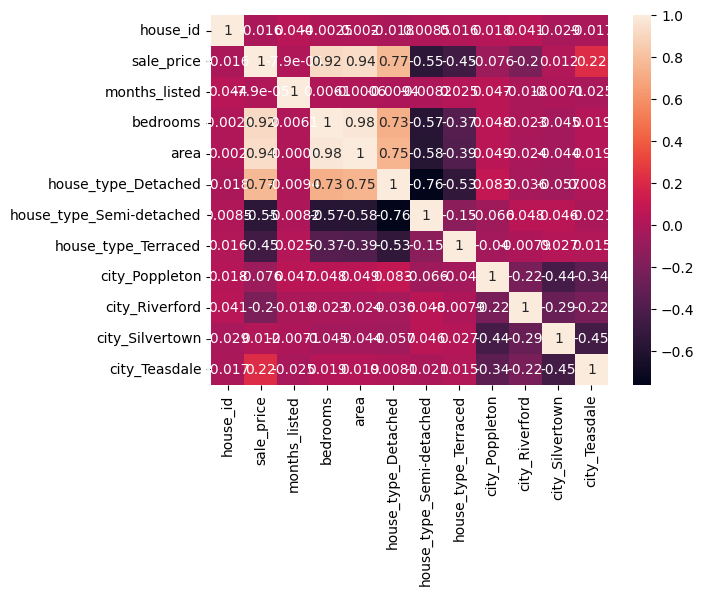

In [18]:
# Use this cell to write your code for Task 4

df_train =  pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/train.xlsx')
df_test = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/test.xlsx')

df_train = pd.get_dummies(df_train, columns=['house_type', 'city'])
df_test = pd.get_dummies(df_test, columns=['house_type', 'city'])


print(df_train.shape, df_test.shape)
print(df_train.info())
print(df_test.info())

columns_corr = ['house_id', 'sale_price', 'months_listed', 'bedrooms','area', 'house_type_Detached', 'house_type_Semi-detached', 'house_type_Terraced',  'city_Poppleton', 'city_Riverford', 'city_Silvertown', 'city_Teasdale' ]

df_train_corr = df_train[columns_corr].corr()
df_train_corr

sns.heatmap(df_train_corr, annot=True)





In [19]:

# #---- Estimate model
columns_X = ['bedrooms', 'area', 'house_type_Detached', 'house_type_Semi-detached', 'house_type_Terraced', 'city_Poppleton', 'city_Riverford', 'city_Silvertown', 'city_Teasdale']

X_train =  df_train[columns_X]
y_train = df_train['sale_price']
X_test = df_test[columns_X]


model = LinearRegression()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

r2 = model.score(X_train, y_train)

print(r2)

base_result = pd.DataFrame(data= {'house_id': df_test['house_id'], 'price': y_hat})

base_result




0.9661903993049853


,house_id,price
0,1331375,120675.004842
1,1630115,303993.021220
2,1645745,383985.518843
3,1336775,122480.569518
4,1888274,271257.598728
...,...,...
295,1986255,353273.831343
296,1896276,368854.081995
297,1758223,257087.905748
298,1752010,170929.629198


# Task 5

Fit a comparison model to predict the sale price of a house.

 1. Fit your model using the data contained in “train.csv” </br></br>

 2. Use “validation.csv” to predict new values based on your model. You must return a dataframe named `compare_result`, that includes `house_id` and `price`. The price column must be your predicted values.

In [22]:
# Use this cell to write your code for Task 5

import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression, Lasso, Ridge
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import OneHotEncoder, LabelEncoder
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, KFold
from sklearn.metrics import r2_score

import math


df_train =  pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/train.xlsx')
df_test = pd.read_excel('/content/drive/MyDrive/Colab_Notebooks/DataScienceModels/DataCamp/Datasets/HouseSales/test.xlsx')

print(df_train.shape, df_test.shape)
print(df_train.info())
print(df_test.info())


df_train = pd.get_dummies(df_train, columns=['house_type', 'city'])
df_test = pd.get_dummies(df_test, columns=['house_type', 'city'])


#---- Estimate model
columns_X = ['bedrooms', 'area', 'house_type_Detached', 'house_type_Semi-detached', 'house_type_Terraced', 'city_Poppleton', 'city_Riverford', 'city_Silvertown', 'city_Teasdale']

X_train =  df_train[columns_X]
y_train = df_train['sale_price']
X_test = df_test[columns_X]


model = RandomForestRegressor()
model.fit(X_train, y_train)
y_hat = model.predict(X_test)

r2 = model.score(X_train, y_train)

print(r2)

compare_result = pd.DataFrame(data= {'house_id': df_test['house_id'], 'price': y_hat})

compare_result






(1200, 9) (300, 8)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1200 entries, 0 to 1199
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          1200 non-null   int64  
 1   house_id       1200 non-null   int64  
 2   city           1200 non-null   object 
 3   sale_price     1200 non-null   int64  
 4   sale_date      1200 non-null   object 
 5   months_listed  1200 non-null   float64
 6   bedrooms       1200 non-null   int64  
 7   house_type     1200 non-null   object 
 8   area           1200 non-null   float64
dtypes: float64(2), int64(4), object(3)
memory usage: 84.5+ KB
None
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300 entries, 0 to 299
Data columns (total 8 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   index          300 non-null    int64  
 1   house_id       300 non-null    int64  
 2   city           300 non-null    object 

,house_id,price
0,1331375,81300.650000
1,1630115,304626.688667
2,1645745,400895.560000
3,1336775,107908.580000
4,1888274,268737.980000
...,...,...
295,1986255,361151.370000
296,1896276,373068.640000
297,1758223,268508.400000
298,1752010,176153.820000


In [23]:
# Calcula manualmente RMSE
y_hat_1 = base_result['price']
y_hat_2 = compare_result['price']

MSE = np.square(np.subtract(y_hat_1, y_hat_2)).mean()
RMSE = math.sqrt(MSE)

print(f'RMSE: {RMSE}' )

RMSE: 18779.382322652567
